
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


Creating ship and background patches...


100%|██████████| 2000/2000 [00:11<00:00, 169.01it/s]


Ship patches: 2000
Background patches: 2000
Classes: ['background', 'ship']
Train samples: 3200
Val samples: 800
MSRFNetPP(
  (spatial3): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (spatial5): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (spatial_fuse): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (freq): Sequential(
    (0)

Epoch 1/10: 100%|██████████| 100/100 [01:43<00:00,  1.03s/it]


Epoch [1/10] | Loss: 0.2524 | Val Accuracy: 97.75%


...

Epoch [8/10] | Loss: 0.0493 | Val Accuracy: 99.38%


Epoch 9/10: 100%|██████████| 100/100 [01:44<00:00,  1.04s/it]


Epoch [9/10] | Loss: 0.0439 | Val Accuracy: 99.38%


Epoch 10/10: 100%|██████████| 100/100 [01:45<00:00,  1.05s/it]


Epoch [10/10] | Loss: 0.0459 | Val Accuracy: 98.75%


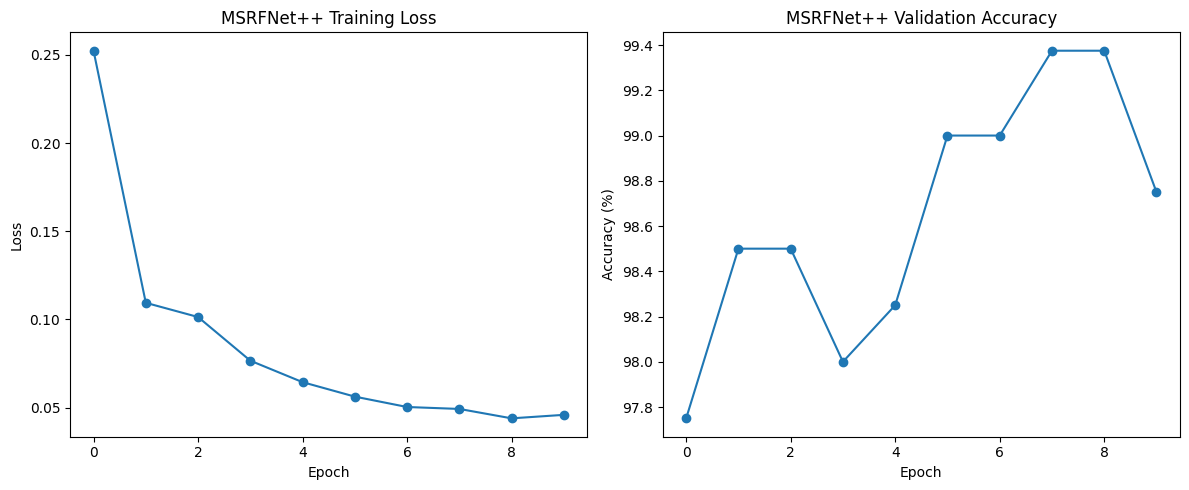

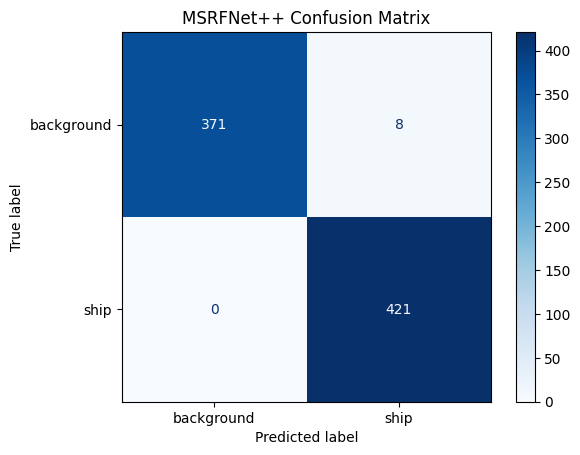

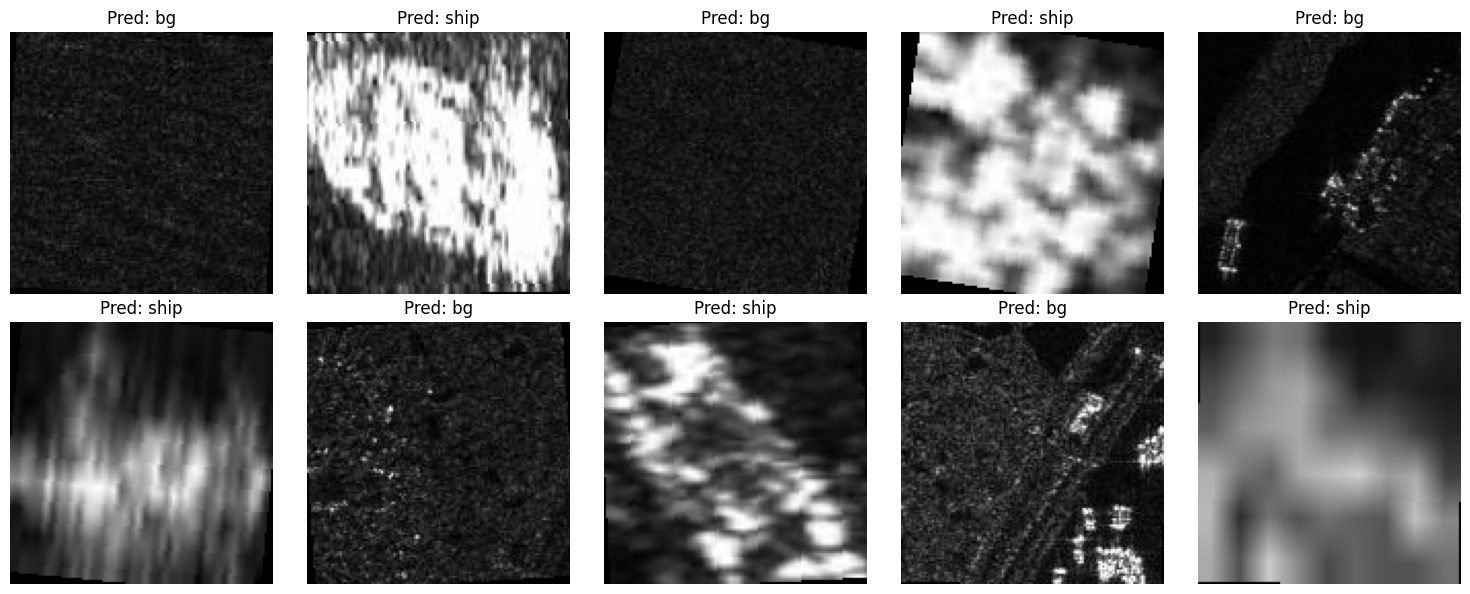

In [8]:
# ============================================
# MSRFNet++: Improved Multi-Scale Residual Frequency Fusion Network
# Full end-to-end Kaggle notebook code
# (Patch extraction + DataLoader + Model + Training + Evaluation)
# ============================================

# ---------- 1. Imports ----------
import os
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------- 2. Paths ----------
train_img_dir = "/kaggle/input/datasets/kailaspsudheer/sarscope-unveiling-the-maritime-landscape/SARscope/train"
ann_path = "/kaggle/input/datasets/kailaspsudheer/sarscope-unveiling-the-maritime-landscape/SARscope/train/_annotations.coco.json"

output_dir = "/kaggle/working/patch_dataset"
ship_dir = os.path.join(output_dir, "ship")
bg_dir = os.path.join(output_dir, "background")

os.makedirs(ship_dir, exist_ok=True)
os.makedirs(bg_dir, exist_ok=True)

# ---------- 3. Patch Extraction ----------
with open(ann_path, "r") as f:
    coco = json.load(f)

image_map = {img["id"]: img["file_name"] for img in coco["images"]}

count_ship = 0
count_bg = 0

print("Creating ship and background patches...")

for ann in tqdm(coco["annotations"][:2000]):  # subset for faster training
    image_id = ann["image_id"]
    file_name = image_map[image_id]
    img_path = os.path.join(train_img_dir, file_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    x, y, w, h = map(int, ann["bbox"])

    # Ship patch
    ship_crop = img[max(0, y):y+h, max(0, x):x+w]
    if ship_crop.size > 0:
        ship_crop = cv2.resize(ship_crop, (128, 128))
        cv2.imwrite(os.path.join(ship_dir, f"ship_{count_ship}.jpg"), ship_crop)
        count_ship += 1

    # Background patch
    H, W = img.shape[:2]
    bx = random.randint(0, max(1, W - 128))
    by = random.randint(0, max(1, H - 128))

    bg_crop = img[by:by+128, bx:bx+128]
    if bg_crop.shape[0] == 128 and bg_crop.shape[1] == 128:
        cv2.imwrite(os.path.join(bg_dir, f"bg_{count_bg}.jpg"), bg_crop)
        count_bg += 1

print(f"Ship patches: {count_ship}")
print(f"Background patches: {count_bg}")


# ---------- 4. DataLoader with Augmentation ----------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(output_dir, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", dataset.classes)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


# ---------- 5. SE Attention Block ----------
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.fc(x)
        return x * weights


# ---------- 6. MSRFNet++ ----------
class MSRFNetPP(nn.Module):
    def __init__(self):
        super(MSRFNetPP, self).__init__()

        # Multi-scale spatial branch
        self.spatial3 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.spatial5 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.spatial_fuse = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Frequency branch
        self.freq = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Learnable fusion weight
        self.alpha = nn.Parameter(torch.tensor(0.5))

        # SE attention
        self.se = SEBlock(64)

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        # Multi-scale spatial branch
        s3 = self.spatial3(x)
        s5 = self.spatial5(x)

        spatial = torch.cat([s3, s5], dim=1)
        spatial = self.spatial_fuse(spatial)
        spatial = spatial.view(spatial.size(0), -1)

        # Frequency branch
        fft = torch.fft.fft2(x)
        fft = torch.abs(fft)

        freq = self.freq(fft)
        freq = freq.view(freq.size(0), -1)

        # Residual fusion
        fused = spatial + self.alpha * freq

        # SE attention refinement
        fused = self.se(fused)

        # Classification
        out = self.fc(fused)

        return out


# ---------- 7. Setup ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MSRFNetPP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

print(model)
print("Using device:", device)


# ---------- 8. Training ----------
epochs = 10

train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.2f}%")


# ---------- 9. Plot Training Curves ----------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("MSRFNet++ Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, marker='o')
plt.title("MSRFNet++ Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()


# ---------- 10. Confusion Matrix ----------
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['background', 'ship']
)

disp.plot(cmap='Blues')
plt.title("MSRFNet++ Confusion Matrix")
plt.show()


# ---------- 11. Sample Predictions ----------
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(f"Pred: {'ship' if preds[i] == 1 else 'bg'}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Creating ship and background patches...


100%|██████████| 2000/2000 [00:11<00:00, 172.68it/s]


Ship patches: 2000
Background patches: 2000
Classes: ['background', 'ship']
Train samples: 3200
Val samples: 800
HybridSFSNet(
  (spatial): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (freq): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (attn): Sequentia

Epoch 1/5: 100%|██████████| 100/100 [00:36<00:00,  2.73it/s]


Epoch [1/5] | Loss: 0.2296 | Val Accuracy: 97.50%


...

Epoch [3/5] | Loss: 0.0530 | Val Accuracy: 97.88%


Epoch 4/5: 100%|██████████| 100/100 [00:36<00:00,  2.75it/s]


Epoch [4/5] | Loss: 0.0365 | Val Accuracy: 98.00%


Epoch 5/5: 100%|██████████| 100/100 [00:36<00:00,  2.76it/s]


Epoch [5/5] | Loss: 0.0392 | Val Accuracy: 98.25%


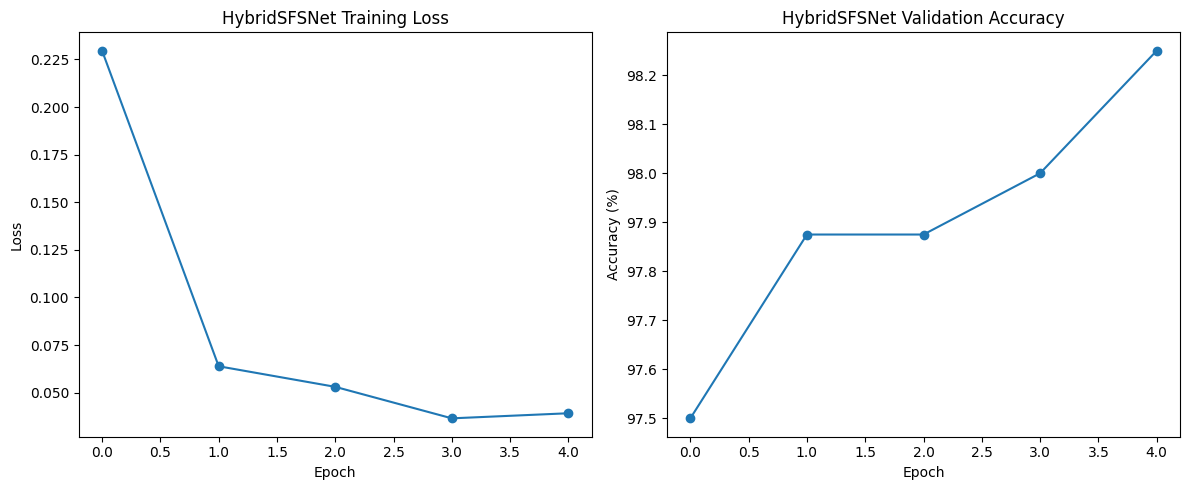

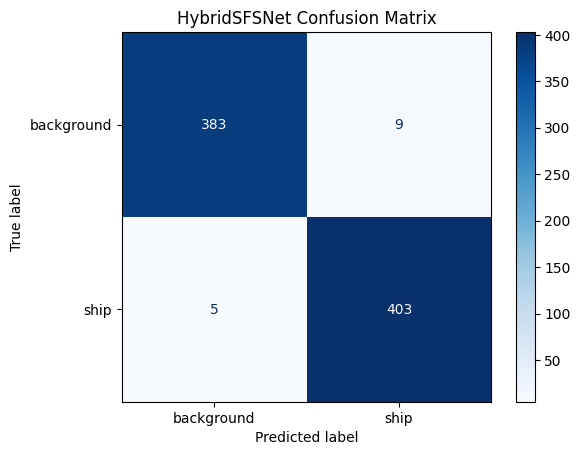

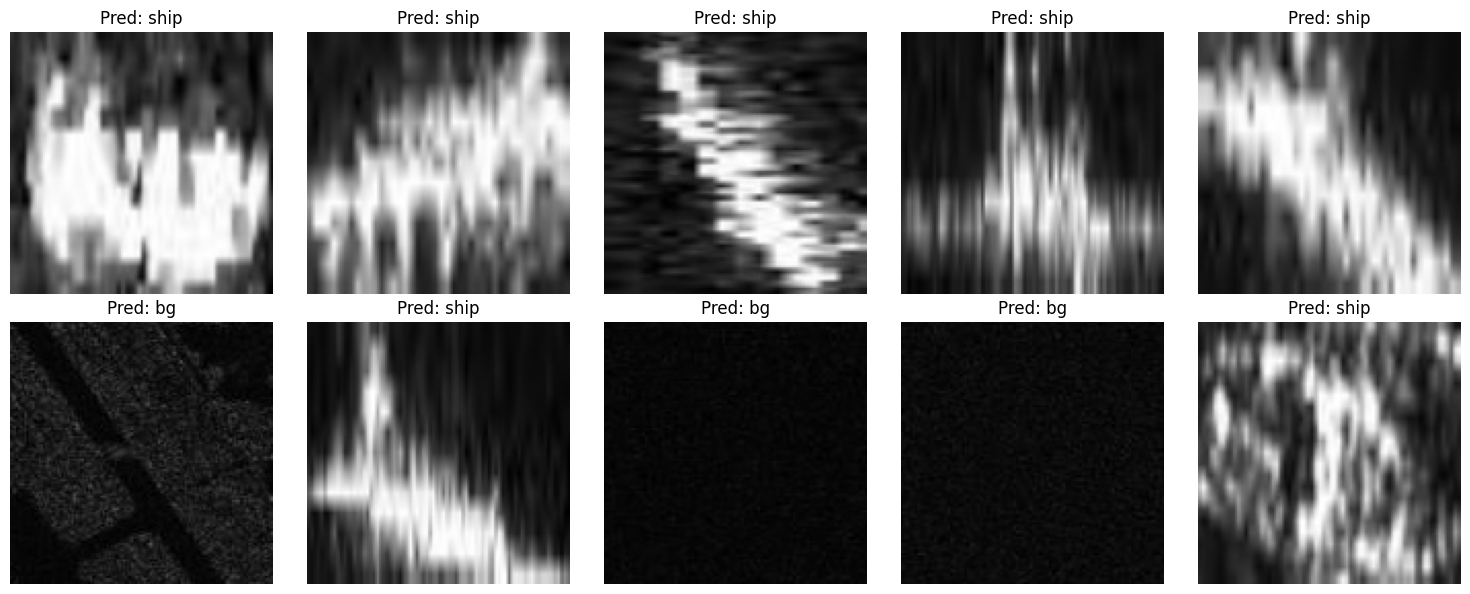

In [7]:
# ============================================
# Original Hybrid SFS-inspired CNN (Baseline)
# Full end-to-end Kaggle notebook code
# (Patch extraction + DataLoader + Model + Training + Evaluation)
# ============================================

# ---------- 1. Imports ----------
import os
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------- 2. Paths ----------
train_img_dir = "/kaggle/input/datasets/kailaspsudheer/sarscope-unveiling-the-maritime-landscape/SARscope/train"
ann_path = "/kaggle/input/datasets/kailaspsudheer/sarscope-unveiling-the-maritime-landscape/SARscope/train/_annotations.coco.json"

output_dir = "/kaggle/working/patch_dataset"
ship_dir = os.path.join(output_dir, "ship")
bg_dir = os.path.join(output_dir, "background")

os.makedirs(ship_dir, exist_ok=True)
os.makedirs(bg_dir, exist_ok=True)

# ---------- 3. Patch Extraction ----------
with open(ann_path, "r") as f:
    coco = json.load(f)

image_map = {img["id"]: img["file_name"] for img in coco["images"]}

count_ship = 0
count_bg = 0

print("Creating ship and background patches...")

for ann in tqdm(coco["annotations"][:2000]):  # subset for faster CPU training
    image_id = ann["image_id"]
    file_name = image_map[image_id]
    img_path = os.path.join(train_img_dir, file_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    x, y, w, h = map(int, ann["bbox"])

    # Ship patch
    ship_crop = img[max(0, y):y+h, max(0, x):x+w]
    if ship_crop.size > 0:
        ship_crop = cv2.resize(ship_crop, (128, 128))
        cv2.imwrite(os.path.join(ship_dir, f"ship_{count_ship}.jpg"), ship_crop)
        count_ship += 1

    # Background patch
    H, W = img.shape[:2]
    bx = random.randint(0, max(1, W - 128))
    by = random.randint(0, max(1, H - 128))

    bg_crop = img[by:by+128, bx:bx+128]
    if bg_crop.shape[0] == 128 and bg_crop.shape[1] == 128:
        cv2.imwrite(os.path.join(bg_dir, f"bg_{count_bg}.jpg"), bg_crop)
        count_bg += 1

print(f"Ship patches: {count_ship}")
print(f"Background patches: {count_bg}")


# ---------- 4. DataLoader ----------
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(output_dir, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Classes:", dataset.classes)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))


# ---------- 5. Original Hybrid SFS-inspired CNN ----------
class HybridSFSNet(nn.Module):
    def __init__(self):
        super(HybridSFSNet, self).__init__()

        # Spatial branch
        self.spatial = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Frequency branch
        self.freq = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Attention fusion
        self.attn = nn.Sequential(
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Linear(64, 96),
            nn.Sigmoid()
        )

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # Spatial features
        s = self.spatial(x)
        s = s.view(s.size(0), -1)

        # Frequency features
        fft = torch.fft.fft2(x)
        fft = torch.abs(fft)

        f = self.freq(fft)
        f = f.view(f.size(0), -1)

        # Attention fusion
        combined = torch.cat([s, f], dim=1)

        attn_weights = self.attn(combined)
        combined = combined * attn_weights

        out = self.fc(combined)

        return out


# ---------- 6. Setup ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridSFSNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Using device:", device)


# ---------- 7. Training ----------
epochs = 5

train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.2f}%")


# ---------- 8. Plot Training Curves ----------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("HybridSFSNet Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, marker='o')
plt.title("HybridSFSNet Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()


# ---------- 9. Confusion Matrix ----------
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['background', 'ship']
)

disp.plot(cmap='Blues')
plt.title("HybridSFSNet Confusion Matrix")
plt.show()


# ---------- 10. Sample Predictions ----------
images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)
    ax.imshow(img)
    ax.set_title(f"Pred: {'ship' if preds[i] == 1 else 'bg'}")
    ax.axis('off')

plt.tight_layout()
plt.show()

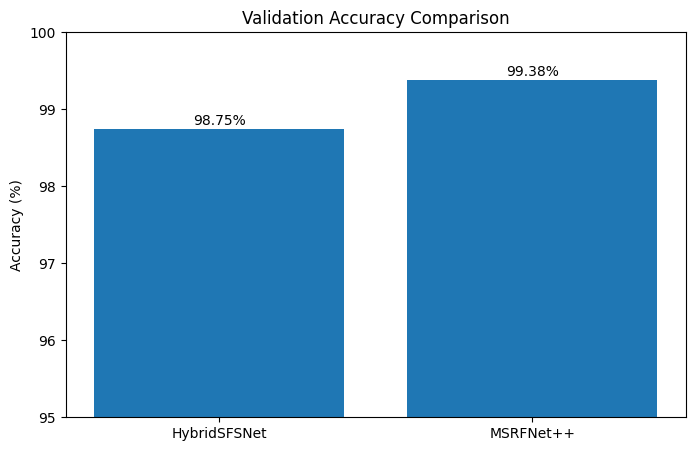

In [11]:
import matplotlib.pyplot as plt

models = ['HybridSFSNet', 'MSRFNet++']
accuracies = [98.75, 99.38]  

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(95, 100)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.05, f"{y:.2f}%", ha='center')

plt.show()